# Neural ODE Influenza Forecaster -- Part 1: Data

This notebook is the first of three. It covers everything needed to understand
the competition data before any modeling decisions are made.

**Three-notebook structure:**
- **Part 1 (this notebook):** Data -- what we have, where it comes from, how it behaves
- **Part 2:** Model -- the Neural ODE architecture, training, uncertainty quantification, and offline evaluation
- **Part 3:** Competition workflow -- the live submission interface

---

## Background: the competition data-generating process

The competition target is weekly influenza hospitalizations per 100,000 people,
simulated from a two-strain SIR model with waning cross-immunity. The two strains
cause two overlapping epidemic waves; the cross-immunity means a prior infection with
strain 1 provides partial but not full protection against strain 2.

This is more complex than a textbook SIR for two reasons. First, there are
effectively eight parameters (two betas, two gammas, cross-immunity strength,
waning rate, and two initial conditions), most of which are non-identifiable from
aggregate hospitalization data alone. Second, the hospitalization curve can be
bimodal (two distinct peaks) or unimodal depending on the parameter regime,
meaning the shape of the curve is not fixed in advance.

The Neural ODE bypasses parameter identification entirely: instead of fitting the
mechanistic equations, we train a neural network to learn whatever latent dynamics
best explain the observed data.

## Competition protocol

- **Initial release:** weeks 1-10 (10 data points). No submission yet.
- **Round 1:** train on weeks 1-10, submit forecasts for weeks 11-15.
- **Round 2:** train on weeks 1-15, submit forecasts for weeks 16-20.
- **Round 3:** train on weeks 1-20, submit forecasts for weeks 21-25.
- **Round 4:** train on weeks 1-25, submit forecasts for weeks 26-30.

Each submission requires a hospitalization rate (per 100k) and R(t) for each of
the 5 forecast weeks.

## 1. Setup

In [1]:
# torchdiffeq provides the ODE solvers (Dopri5 / RK45 by default) and the adjoint method
!pip install torchdiffeq --quiet

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy
import io
from torchdiffeq import odeint_adjoint as odeint

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.14.1


In [3]:
DATA_DIR = '../data'   # directory containing the competition CSVs

def load_season(filename):
    """
    Load one competition CSV into a tidy two-column DataFrame
    with columns ['week', 'hospitalizations'].

    All files share the same format:
      - UTF-8 BOM at the start (encoding='utf-8-sig' strips it)
      - First column:  week (integer, 1-indexed)
      - Second column: hospitalizations per 100k (float)

    We rename regardless of the exact column headers.
    """
    df = pd.read_csv(filename, encoding='utf-8-sig')
    cols = df.columns.tolist()
    df = df.rename(columns={cols[0]: 'week', cols[1]: 'hospitalizations'})
    df['week']            = df['week'].astype(int)
    df['hospitalizations'] = df['hospitalizations'].astype(float)
    print(f'Loaded {filename}: {len(df)} weeks, '
          f'peak {df["hospitalizations"].max():.3f} per 100k '
          f'at week {df["hospitalizations"].idxmax() + 1}')
    return df


df_competition = load_season(f'{DATA_DIR}/releases/release-05.csv')
df_2017        = load_season(f'{DATA_DIR}/raw/influenzaA2017.csv')
df_2018        = load_season(f'{DATA_DIR}/raw/influenzaA2018.csv')

print('\nData preview (first 10 weeks):')
print(df_competition.head(10).to_string(index=False))

Loaded ../data/releases/release-05.csv: 30 weeks, peak 5.300 per 100k at week 21
Loaded ../data/raw/influenzaA2017.csv: 30 weeks, peak 8.400 per 100k at week 14
Loaded ../data/raw/influenzaA2018.csv: 30 weeks, peak 5.100 per 100k at week 24

Data preview (first 10 weeks):
 week  hospitalizations
    1               0.1
    2               0.1
    3               0.2
    4               0.3
    5               0.4
    6               0.5
    7               0.6
    8               0.8
    9               1.0
   10               1.3


## 2. Normalization

The Neural ODE learns the *shape* of the epidemic curve, not its absolute scale.
A season peaking at 5 per 100k and one peaking at 20 per 100k may share the same
underlying dynamics -- normalization lets one network represent both.

We normalize by dividing by the season maximum, mapping hospitalizations to [0, 1].
The scale factor is stored so forecasts can be converted back to per-100k units.

One subtle but important point: in the live competition we cannot normalize by the
season maximum because we do not know it yet. The `CompetitionSession` in Part 3
fixes the scale to the maximum of the first batch received and reuses it for all
subsequent rounds. This avoids shifting the normalization target as more data arrives,
which would destabilize training.

In [4]:
def normalize_season(df):
    """
    Normalize hospitalizations to [0, 1] by the season maximum.
    Returns (normalized_array, scale_factor).
    We store the scale factor to convert predictions back to per-100k.

    Why normalize? The network should learn *shape* (dynamics), not scale.
    A season peaking at 5 per 100k and one peaking at 20 per 100k may share
    the same underlying curve shape -- normalization lets the same network
    represent both.
    """
    H = df['hospitalizations'].values.astype(np.float32)
    scale = float(H.max())
    return H / scale, scale


H_comp,  scale_comp  = normalize_season(df_competition)
H_2017,  scale_2017  = normalize_season(df_2017)          # peak  8.4   per 100k
H_2018,  scale_2018  = normalize_season(df_2018)          # peak  5.1   per 100k

weeks_comp  = df_competition['week'].values
weeks_2017  = df_2017['week'].values
weeks_2018  = df_2018['week'].values

print(f'Competition scale: {scale_comp:.3f} per 100k  ({len(H_comp)} weeks)')
print(f'2017 scale:        {scale_2017:.3f} per 100k  ({len(H_2017)} weeks)')
print(f'2018 scale:        {scale_2018:.3f} per 100k  ({len(H_2018)} weeks)')

Competition scale: 5.300 per 100k  (30 weeks)
2017 scale:        8.400 per 100k  (30 weeks)
2018 scale:        5.100 per 100k  (30 weeks)


## 3. Exploratory Visualization

Three things to look for in these plots:

1. **Shape:** Is the epidemic unimodal (single peak) or bimodal? The Neural ODE
   needs to represent whatever shape the data has.
2. **Scale:** How large is the peak? This determines whether normalization is
   important for numerical stability.
3. **Duration:** How many weeks does the epidemic last? This sets the scale of
   the forecasting problem -- 30 weeks of data is little for any learning method.

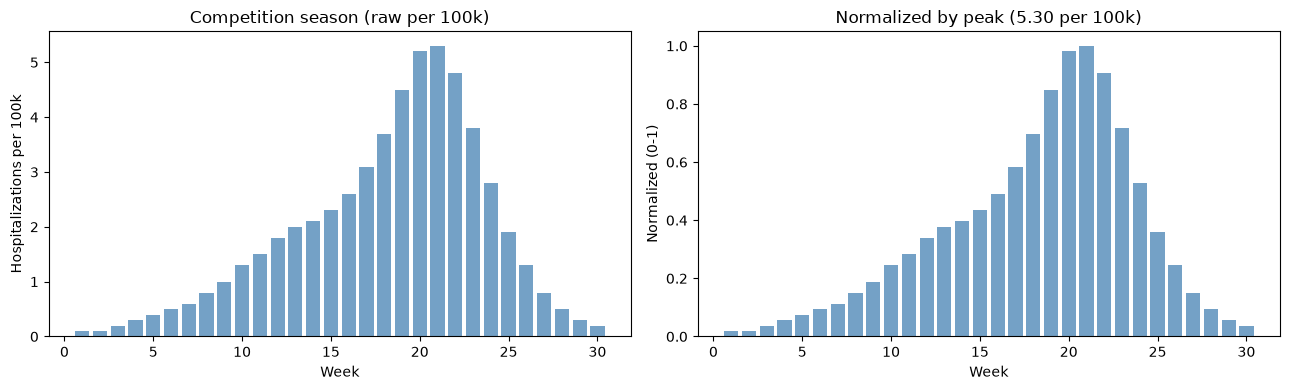

Season length: 30 weeks
Peak:          5.30 per 100k at week 21
Min:           0.10 per 100k


In [5]:
H_full_viz = df_competition['hospitalizations'].values.astype(float)
weeks_viz  = df_competition['week'].values
scale_viz  = H_full_viz.max()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(weeks_viz, H_full_viz, color='steelblue', alpha=0.75)
ax.set_xlabel('Week')
ax.set_ylabel('Hospitalizations per 100k')
ax.set_title('Competition season (raw per 100k)')
ax.set_ylim(0, None)

ax2 = axes[1]
H_norm_viz = H_full_viz / scale_viz
ax2.bar(weeks_viz, H_norm_viz, color='steelblue', alpha=0.75)
ax2.set_xlabel('Week')
ax2.set_ylabel('Normalized (0-1)')
ax2.set_title(f'Normalized by peak ({scale_viz:.2f} per 100k)')

plt.tight_layout()
plt.show()

print(f'Season length: {len(H_full_viz)} weeks')
print(f'Peak:          {H_full_viz.max():.2f} per 100k at week {weeks_viz[H_full_viz.argmax()]}')
print(f'Min:           {H_full_viz.min():.2f} per 100k')

## 4. Incremental Release Schedule

A key feature of this competition is that data arrives in batches. You never have
the full season when submitting -- you see only the weeks released so far.

This matters because:
- In early rounds (10 data points), you are forecasting into a regime you have
  never seen. The epidemic may still be growing, and you cannot know the peak.
- In late rounds (25 data points), you have seen the peak and the beginning of
  decline. The forecast is much more constrained.

The cutoff list below defines exactly what data is available at each submission.

In [6]:
# Cutoff weeks: the last week of data available at each release
RELEASE_CUTOFFS = [10, 15, 20, 25]
FORECAST_HORIZON = 5  # weeks to predict beyond each cutoff

print('Release schedule:')
for c in RELEASE_CUTOFFS:
    print(f'  Weeks 0-{c} available -> forecast weeks {c+1} to {c+FORECAST_HORIZON}')

Release schedule:
  Weeks 0-10 available -> forecast weeks 11 to 15
  Weeks 0-15 available -> forecast weeks 16 to 20
  Weeks 0-20 available -> forecast weeks 21 to 25
  Weeks 0-25 available -> forecast weeks 26 to 30


## 5. First-Difference Analysis

Before fitting any model, it is worth looking at the week-over-week change in
hospitalizations. This is the quantity that must eventually go from positive
(growing epidemic) to negative (declining), and models that do not track this
well will produce systematically biased forecasts.

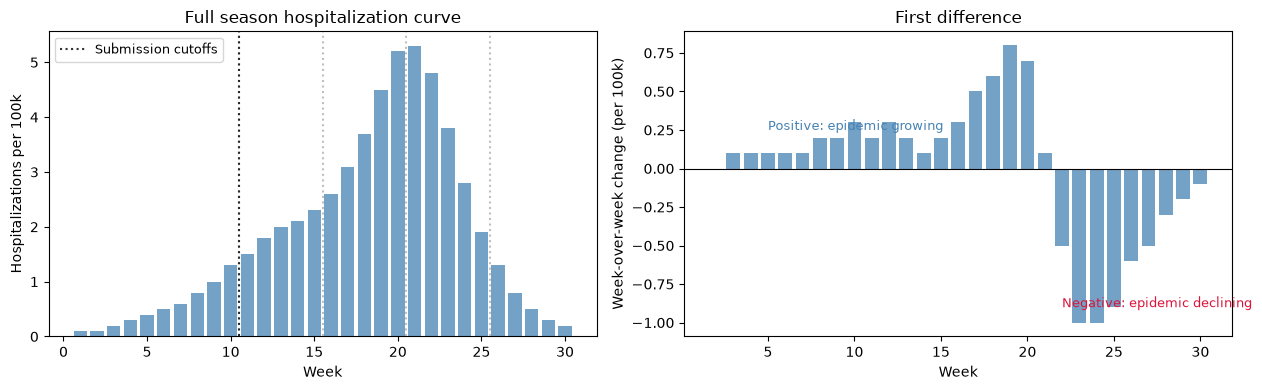

Peak: 5.30 per 100k at week 21
First difference crosses zero near week 21 (the peak).

At each submission round, the model sees only the data up to the cutoff.
The first-difference plot shows what shape the model is extrapolating from:
  Cutoff week 10: last observed change = +0.20  (growing)
  Cutoff week 15: last observed change = +0.30  (growing)
  Cutoff week 20: last observed change = +0.10  (growing)
  Cutoff week 25: last observed change = -0.60  (declining)


In [7]:
import numpy as np
import matplotlib.pyplot as plt

H_full    = df_competition['hospitalizations'].values.astype(float)
weeks_all = df_competition['week'].values

dH = np.diff(H_full)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(weeks_all, H_full, color='steelblue', alpha=0.75)
for c in [10, 15, 20, 25]:
    ax.axvline(c + 0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(10.5, color='black', linestyle=':', alpha=0.8, label='Submission cutoffs')
ax.set_xlabel('Week')
ax.set_ylabel('Hospitalizations per 100k')
ax.set_title('Full season hospitalization curve')
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.bar(weeks_all[1:], dH, color='steelblue', alpha=0.75)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Week')
ax2.set_ylabel('Week-over-week change (per 100k)')
ax2.set_title('First difference')
ax2.annotate('Positive: epidemic growing', xy=(5, 0.25), fontsize=9, color='steelblue')
ax2.annotate('Negative: epidemic declining', xy=(22, -0.9), fontsize=9, color='crimson')

plt.tight_layout()
plt.show()

peak_week = weeks_all[np.argmax(H_full)]
print(f'Peak: {H_full.max():.2f} per 100k at week {peak_week}')
print(f'First difference crosses zero near week {peak_week} (the peak).')
print()
print('At each submission round, the model sees only the data up to the cutoff.')
print('The first-difference plot shows what shape the model is extrapolating from:')
for c in [10, 15, 20, 25]:
    dH_at_cutoff = dH[c-1]   # change at the last observed week
    trend = 'growing' if dH_at_cutoff > 0 else 'declining'
    print(f'  Cutoff week {c}: last observed change = {dH_at_cutoff:+.2f}  ({trend})')

## Summary

What this notebook establishes:

- The competition data comes from a two-strain SIR model; the season has one broad
  peak, 5.3 per 100k at week 21.
- Normalizing by the season maximum maps the curve to [0, 1]; we fix the scale to
  the first-batch maximum in the live competition.
- The four submission rounds see 10, 15, 20, and 25 weeks respectively. The first
  three rounds observe only the growth phase (the peak is at week 21); the fourth
  round has seen the peak and the start of the decline.
- The first-difference plot clarifies what each model is extrapolating from at each
  cutoff -- this is the right frame for understanding why model behavior changes
  across rounds.

Proceed to **Part 2** to see the Neural ODE architecture and offline evaluation.